In [1212]:
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import emcee
import random
from find_source import summary

In [1213]:
def const_fn_red_chi2(y_and_sd, const):
    chi2 = 0
    for tup in y_and_sd:
        y, sd = tup
        chi2 += ((y-const)/sd)**2
    df = len(y_and_sd) - 1
    return chi2/df

In [1214]:
def test_naive_uv_fitting(data):#fits_file: str):
    # file = fits.open(fits_file)
    # data = file[1].data
    vis = np.array(data)
    freq_bin, u, v, Re, Im, w = [], [], [], [], [], []
    for row in vis:
        freq_bin_data, u_data, v_data, Re_data, Im_data, w_data = row
        freq_bin.append(int(freq_bin_data))
        u.append(int(u_data))
        v.append(int(v_data))
        Re.append(float(Re_data/w_data))
        Im.append(float(Im_data/w_data))
        w.append(float(w_data))

    # adding in conjugate half of data
    freq_bin *= 2
    neg_u = [-1 * val for val in u]
    u += neg_u
    neg_v = [-1 * val for val in v]
    v += neg_v
    Re *= 2
    neg_Im = [-1 * val for val in Im]
    Im += neg_Im
    w *= 2
    Rlambda = []
    for i in range(len(u)):
        Rlambda.append((u[i]**2 +v[i]**2)**(1/2))

    sd = [weight**(-1/2) for weight in w]
    amp_dat = []
    re_dat = []
    im_dat = []
    for i in range(len(sd)):
        amp_dat.append(((Re[i]**2 + Im[i]**2)**(1/2), sd[i]))
        re_dat.append((Re[i], sd[i]))
        im_dat.append((Im[i], sd[i]))
    zeroes = [0]*len(amp_dat)

    amp_popt, amp_pcov = curve_fit(const_fn_red_chi2, amp_dat, zeroes)
    amp_red_chi2 = const_fn_red_chi2(amp_dat, float(amp_popt))
    amp_dict = {'val': float(amp_popt[0]), 'sd': float(amp_pcov[0][0]**(1/2)), 'red_chi2': amp_red_chi2}

    re_popt, re_pcov = curve_fit(const_fn_red_chi2, re_dat, zeroes)
    re_red_chi2 = const_fn_red_chi2(re_dat, float(re_popt))
    re_dict = {'val': float(re_popt[0]), 'sd': float(re_pcov[0][0]**(1/2)), 'red_chi2': re_red_chi2}

    im_popt, im_pcov = curve_fit(const_fn_red_chi2, im_dat, zeroes)
    im_red_chi2 = const_fn_red_chi2(im_dat, float(im_popt))
    im_dict = {'val': float(im_popt[0]), 'sd': float(im_pcov[0][0]**(1/2)), 'red_chi2': im_red_chi2}

    return {'amp': amp_dict, 're': re_dict, 'im': im_dict}


In [1215]:
# logarithmic likelihood function (for Gaussian probability)
def log_likelihood(b, y, yerr):
    model = b
    sigma2 = yerr**2
    return -0.5 * np.sum((y - model) ** 2 / sigma2) #+ np.log(2*np.pi*sigma2))

In [1216]:
def log_prior(b):
    if -20.0 < b < 20.0: # this range is for testing purposes
        return 0.0
    return -np.inf

In [1217]:
def log_probability(b, y, yerr):
    lp = log_prior(b)
    if not np.isfinite(lp): # if outside of range where m, b, log(f) could be
        return -np.inf # essentially 0 probability (e^-inf = 0)
    return lp + log_likelihood(b, y, yerr)

In [1218]:
def test_mcmc_single_pt_source(data):#fits_file: str):
    # TODO: generalize to fitting n point/disk/Gaussian sources

    vis = np.array(data)
    freq_bin, u, v, Re, Im, w = [], [], [], [], [], []
    for row in vis:
        freq_bin_data, u_data, v_data, Re_data, Im_data, w_data = row
        freq_bin.append(int(freq_bin_data))
        u.append(int(u_data))
        v.append(int(v_data))
        Re.append(float(Re_data/w_data))
        Im.append(float(Im_data/w_data))
        w.append(float(w_data))

    # adding in conjugate half of data
    freq_bin *= 2
    neg_u = [-1 * val for val in u]
    u += neg_u
    neg_v = [-1 * val for val in v]
    v += neg_v
    Re *= 2
    neg_Im = [-1 * val for val in Im]
    Im += neg_Im
    w *= 2
    Rlambda = []
    for i in range(len(u)):
        Rlambda.append((u[i]**2 +v[i]**2)**(1/2))

    amp = []
    for i in range(len(Re)):
        amp.append((Re[i]**2 + Im[i]**2)**(1/2))
    sd = [weight**(-1/2) for weight in w]

    # TODO: optional parameters: number of sources (therefore number of dimensions), nsteps, discard number
    nwalkers = 6
    nsteps = 2000
    ndim = 1

    amp_pos = np.random.randn(nwalkers, ndim) * 2 + 10
    # TODO: optional parameters: number of sources (therefore number of dimensions), nsteps, discard number

    amp_sampler = emcee.EnsembleSampler(nwalkers, ndim, log_probability, args=(np.array(amp), np.array(sd)))
    amp_results = amp_sampler.run_mcmc(amp_pos, nsteps)

    # initial positions for Re and Im until I can figure out initial guesses from image domain
    re_pos = np.random.randn(nwalkers, ndim) * 2 + np.average(Re)
    im_pos = np.random.randn(nwalkers, ndim) * 2 + np.average(Im)

    re_sampler = emcee.EnsembleSampler(nwalkers, ndim, log_probability, args=(np.array(Re), np.array(sd)))
    re_results = re_sampler.run_mcmc(re_pos, nsteps)

    im_sampler = emcee.EnsembleSampler(nwalkers, ndim, log_probability, args=(np.array(Im), np.array(sd)))
    im_results = im_sampler.run_mcmc(im_pos, nsteps)

    print(amp_sampler.get_autocorr_time(), re_sampler.get_autocorr_time(), im_sampler.get_autocorr_time())

    return amp_results, re_results, im_results

In [1219]:
# # extract visibility data
# file = fits.open('../data/uv_test/3c84.uvfits')
# data = file[1].data
# vis = np.array(data)
# freq_bin, u, v, Re, Im, w = [], [], [], [], [], []
# for row in vis:
#     freq_bin_data, u_data, v_data, Re_data, Im_data, w_data = row
#     freq_bin.append(int(freq_bin_data))
#     u.append(int(u_data))
#     v.append(int(v_data))
#     Re.append(float(Re_data/w_data))
#     Im.append(float(Im_data/w_data))
#     w.append(float(w_data))

# # adding in conjugate half of data
# freq_bin *= 2
# neg_u = [-1 * val for val in u]
# u += neg_u
# neg_v = [-1 * val for val in v]
# v += neg_v
# Re *= 2
# neg_Im = [-1 * val for val in Im]
# Im += neg_Im
# w *= 2
# Rlambda = []
# for i in range(len(u)):
#     Rlambda.append((u[i]**2 +v[i]**2)**(1/2))

In [1220]:
# # plot visibility data
# fig=plt.figure(figsize=(15,8))
# ax=fig.add_subplot(111)
# meters_u = [u_val / 1300 for u_val in u]
# meters_v = [v_val / 1300 for v_val in v]
# ax.scatter(meters_u,meters_v, c=Re, marker='.', cmap='gist_rainbow')
# ax.set_aspect(aspect=1.0)
# ax.set_xlabel('u (lambda)')
# ax.set_ylabel('v (lambda)')

In [1221]:
# plt.scatter(Rlambda, Re, marker='.')
# weights = np.array(w)
# sd = weights**(-1/2)
# plt.errorbar(x=Rlambda, y=Re, yerr=sd, linestyle='None')

In [1222]:
# np.ma.average(Re, axis=(0,40000,80000,100000,120000,140000,160000,180000))

In [1223]:
# plt.scatter(Rlambda, Im, marker='.')
# plt.errorbar(x=Rlambda, y=Im, yerr=sd, linestyle='None')

In [1224]:
# sd = [weight**(-1/2) for weight in w]

# uv_dat = []
# for i in range(len(sd)):
#     uv_dat.append(((Re[i]**2 + Im[i]**2)**(-1/2), sd[i]))
# zeroes = [0]*len(uv_dat)
# popt, pcov = curve_fit(const_fn_red_chi2, uv_dat, zeroes)
# red_chi2_val = const_fn_red_chi2(uv_dat, float(popt))

In [1225]:
##### FAKE ARRAY IN FORM OF KARTO'S DATA #####
fake_arr = np.tile([float(0)]*6, (20, 1))
for i in range(len(fake_arr)):
    fake_arr[i][1] = i
    fake_arr[i][2] = i
    real = 10
    imag = 0
    x = 1e-3
    re_noise = random.random() * x
    im_noise = random.random() * x
    if random.randint(0,1):
        re_noise *= -1
    if random.randint(0,1):
        im_noise *= -1
    fake_arr[i][3] = real + re_noise
    fake_arr[i][4] = imag + im_noise
    weight = (re_noise**2 + im_noise**2)**(-1)
    fake_arr[i][5] = weight
    fake_arr[i][3] *= weight # weighting reals like Karto
    fake_arr[i][4] *= weight # weighting imaginaries like Karto

In [1226]:
test_naive_uv_fitting(fake_arr)

/var/folders/3j/z5bj43t10vsdnks2s1xw3vm80000gn/T/ipykernel_94532/3563958717.py:40: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  amp_red_chi2 = const_fn_red_chi2(amp_dat, float(amp_popt))
/var/folders/3j/z5bj43t10vsdnks2s1xw3vm80000gn/T/ipykernel_94532/3563958717.py:44: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  re_red_chi2 = const_fn_red_chi2(re_dat, float(re_popt))
/var/folders/3j/z5bj43t10vsdnks2s1xw3vm80000gn/T/ipykernel_94532/3563958717.py:47: OptimizeWarning: Covariance of the parameters could not be estimated
  im_popt, im_pcov = curve_fit(const_fn_red_chi2, im_dat, zeroes)
/var/folders/3j/z5bj43t10vsdnks2s1xw3vm80000gn/T/ipyker

{'amp': {'val': 10.000061024989234,
  'sd': 0.3284953827966051,
  'red_chi2': 0.46001744127622984},
 're': {'val': 10.000061017557796,
  'sd': 0.32849715110541244,
  'red_chi2': 0.46001801346808663},
 'im': {'val': 1.0983584563958071e-10,
  'sd': inf,
  'red_chi2': 0.5517806994382942}}

In [1227]:
##### FAKE ARRAY IN FORM OF KARTO'S DATA #####
fake_arr = np.tile([float(0)]*6, (20, 1))
for i in range(len(fake_arr)):
    fake_arr[i][1] = i
    fake_arr[i][2] = i
    real = 10
    imag = 0
    x = 1e-3
    re_noise = random.random() * x
    im_noise = random.random() * x
    if random.randint(0,1):
        re_noise *= -1
    if random.randint(0,1):
        im_noise *= -1
    fake_arr[i][3] = real + re_noise
    fake_arr[i][4] = imag + im_noise
    weight = (re_noise**2 + im_noise**2)**(-1)
    fake_arr[i][5] = weight
    fake_arr[i][3] *= weight # weighting reals like Karto
    fake_arr[i][4] *= weight # weighting imaginaries like Karto

In [1228]:
test_mcmc_single_pt_source(fake_arr)

[11.30066779] [12.50023753] [9.83252891]


(State([[10.00003972]
  [10.00015329]
  [10.00010219]
  [10.00008667]
  [10.00013019]
  [10.00017692]], log_prob=[ -9.04824914 -10.00472163  -9.19677082  -9.07366451  -9.56296234
  -10.58727337], blobs=None, random_state=('MT19937', array([1214711966, 3721269501,  447946633,  123015883, 1111101712,
        1522242078, 4194633249, 1361937502, 1344269504, 2541713108,
        3336477735,  966325131,  643196901,  356045446, 3580664102,
         399272565,  437639932, 3874579712,  147338971, 1768684451,
        4021903565,  305716880, 1653079813, 2637941701, 2710512577,
        3301788619, 4193922636, 1478766900, 1572728721, 1457145385,
         202938117, 3351453068, 3689640634,  306739991, 1793969178,
         760383354, 3522964445, 1181836255,  118167828,  742776686,
        3063515629,  992314217, 2646175314, 3605535778,  638147127,
        1582078438, 1726711695,   69987814,  791354999, 1335021392,
        2971489068,  915875232, 3934834192, 2403737060,  184992495,
        3331091757, 

In [1229]:
# Rlambda = []
# for i in range(len(u)):
#     Rlambda.append((u[i]**2 +v[i]**2)**(1/2))
# plt.scatter(Rlambda, Re)
# plt.ylim((0,12))

In [1230]:
# plt.scatter(Rlambda, Im)
# plt.ylim((-1,1))

In [1231]:
def initial_guess(fits_file):
    summ = summary(fits_file, plot=False)
    peak_coords = summ['int_peak_val']
    if type(summ['ext_peak_val']) == list:
        peak_coords += summ['ext_peak_val']
    return peak_coords, summ['conservative_rms']

In [1248]:
fits.open('../data/uv_test/at2024tvd.fits')[1].data

FITS_rec([(0, 18,  0, 420.6604   , -275.8114   , 86699.3    ),
          (0, 19,  0,  24.46373  ,  -94.33884  , 32877.39   ),
          (0, 20,  0, 145.33069  ,   -2.4174213, 40204.633  ), ...,
          (1,  7, 50,   6.2507386,  -45.22141  ,  1108.3508 ),
          (1,  8, 50, -27.927786 ,  -17.995735 ,   601.1217 ),
          (1,  9, 50,   7.941753 ,  -14.429062 ,   148.72305)],
         dtype=(numpy.record, [('Frequency bin', '>i4'), ('indexU', '>i2'), ('indexV', '>i2'), ('Re', '>f4'), ('Im', '>f4'), ('Weight', '>f4')]))

{'field_center': (0, 0),
 'rms_val': 0.00012459907156880945,
 'mad': 8.437581709586084e-05,
 'sd_mad': 0.00012440247822720807,
 'n_incl_meas': 18.067356765121,
 'n_excl_meas': 827.7424874767748,
 'fwhm': 3.47508468,
 'incl_radius': 8.47508468,
 'neg_peak': -0.000479929061839357,
 'int_peak_val': [0.0006192037835717201],
 'int_peak_coord': [(0.0, -1.208582849104081)],
 'int_prob': [8.394904258738624e-06],
 'int_snr': [4.969569803172785],
 'ext_peak_val': 'No significant external peak',
 'ext_peak_coord': 'No significant external peak',
 'ext_prob': 'No significant external peak',
 'ext_snr': 'No significant external peak',
 'calc_rms_val': 0.00017520653373480203,
 'neg_peak_rms_val': 0.00015786357421749794,
 'calc_ext_prob': 0.31459587458578914,
 'calc_ext_snr': 3.0336419131631027,
 'calc_int_prob': [0.0007920004356543058],
 'calc_int_snr': [3.922398100011385],
 'conservative_rms': 0.00017520653373480203,
 'conservative_snr': 3.534}

<Figure size 384x288 with 0 Axes>

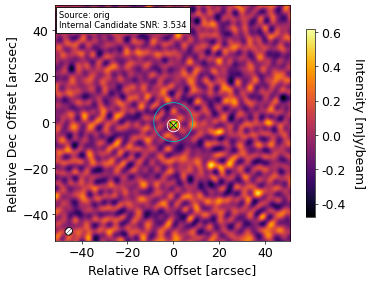

In [1232]:
summary('../data/uv_test/orig.fits')

In [1233]:
initial_guess('../data/uv_test/orig.fits')

([0.0006192037835717201], 0.00017520653373480203)

In [1234]:
def naive_uv_fit(fits_file: str):
    file = fits.open(fits_file)
    data = file[1].data
    vis = np.array(data)
    freq_bin, u, v, Re, Im, w = [], [], [], [], [], []
    for row in vis:
        freq_bin_data, u_data, v_data, Re_data, Im_data, w_data = row
        freq_bin.append(int(freq_bin_data))
        u.append(int(u_data))
        v.append(int(v_data))
        Re.append(float(Re_data/w_data))
        Im.append(float(Im_data/w_data))
        w.append(float(w_data))

    # adding in conjugate half of data
    freq_bin *= 2
    neg_u = [-1 * val for val in u]
    u += neg_u
    neg_v = [-1 * val for val in v]
    v += neg_v
    Re *= 2
    neg_Im = [-1 * val for val in Im]
    Im += neg_Im
    w *= 2
    Rlambda = []
    for i in range(len(u)):
        Rlambda.append((u[i]**2 +v[i]**2)**(1/2))

    sd = [weight**(-1/2) for weight in w]
    amp_dat = []
    re_dat = []
    im_dat = []
    for i in range(len(sd)):
        amp_dat.append(((Re[i]**2 + Im[i]**2)**(1/2), sd[i]))
        re_dat.append((Re[i], sd[i]))
        im_dat.append((Im[i], sd[i]))
    zeroes = [0]*len(amp_dat)

    init_info = initial_guess('../data/uv_test/orig.fits')#fits_file)
    # TODO: figure out how to get real and im inital guesses from summary info

    amp_popt, amp_pcov = curve_fit(const_fn_red_chi2, amp_dat, zeroes, p0=init_info[0][0])
    amp_red_chi2 = const_fn_red_chi2(amp_dat, float(amp_popt))
    amp_dict = {'val': float(amp_popt[0]), 'sd': float(amp_pcov[0][0]**(1/2)), 'red_chi2': amp_red_chi2}

    re_popt, re_pcov = curve_fit(const_fn_red_chi2, re_dat, zeroes)
    re_red_chi2 = const_fn_red_chi2(re_dat, float(re_popt))
    re_dict = {'val': float(re_popt[0]), 'sd': float(re_pcov[0][0]**(1/2)), 'red_chi2': re_red_chi2}

    im_popt, im_pcov = curve_fit(const_fn_red_chi2, im_dat, zeroes)
    im_red_chi2 = const_fn_red_chi2(im_dat, float(im_popt))
    im_dict = {'val': float(im_popt[0]), 'sd': float(im_pcov[0][0]**(1/2)), 'red_chi2': im_red_chi2}

    return {'amp': amp_dict, 're': re_dict, 'im': im_dict}


In [ ]:
def mcmc_uv_fit(fits_file: str):
    # TODO: generalize to fitting n point/disk/Gaussian sources

    file = fits.open(fits_file)
    data = file[1].data
    vis = np.array(data)
    freq_bin, u, v, Re, Im, w = [], [], [], [], [], []
    for row in vis:
        freq_bin_data, u_data, v_data, Re_data, Im_data, w_data = row
        freq_bin.append(int(freq_bin_data))
        u.append(int(u_data))
        v.append(int(v_data))
        Re.append(float(Re_data/w_data))
        Im.append(float(Im_data/w_data))
        w.append(float(w_data))

    # adding in conjugate half of data
    freq_bin *= 2
    neg_u = [-1 * val for val in u]
    u += neg_u
    neg_v = [-1 * val for val in v]
    v += neg_v
    Re *= 2
    neg_Im = [-1 * val for val in Im]
    Im += neg_Im
    w *= 2
    Rlambda = []
    for i in range(len(u)):
        Rlambda.append((u[i]**2 +v[i]**2)**(1/2))

    amp = []
    for i in range(len(Re)):
        amp.append((Re[i]**2 + Im[i]**2)**(1/2))
    sd = [weight**(-1/2) for weight in w]

    nwalkers = 3
    ndim = 1
    nsteps = 5000

    init_info = initial_guess('../data/uv_test/orig.fits')#fits_file)

    amp_pos = np.random.randn(nwalkers, ndim) * init_info[1] + init_info[0][0]
    # TODO: optional parameters: number of sources (therefore number of dimensions), nsteps, discard number

    # pos = np.random.randn(50,1) * 2 + 10
    amp_sampler = emcee.EnsembleSampler(nwalkers, ndim, log_probability, args=(np.array(amp), np.array(sd)))
    amp_results = amp_sampler.run_mcmc(amp_pos, nsteps)

    # initial positions for Re and Im until I can figure out initial guesses from image domain
    re_pos = np.random.randn(nwalkers, ndim) * init_info[1] + np.average(Re)
    im_pos = np.random.randn(nwalkers, ndim) * init_info[1] + np.average(Im)

    re_sampler = emcee.EnsembleSampler(nwalkers, ndim, log_probability, args=(np.array(Re), np.array(sd)))
    re_results = re_sampler.run_mcmc(re_pos, nsteps)

    re_chain = re_sampler.get_chain(discard=2000)
    fig, axes = plt.subplots(1, figsize=(10, 7), sharex=True)
    for i in range(ndim):
        ax = axes
        ax.plot(re_chain[:, :, i], "k", alpha=0.3)
        ax.set_xlim(0, len(re_chain))
        ax.yaxis.set_label_coords(-0.1, 0.5)
        axes.set_xlabel("step number")
    walker1 = re_chain[:, 1]
    print(np.average(walker1))
    print(np.nanstd(walker1))

    im_sampler = emcee.EnsembleSampler(nwalkers, ndim, log_probability, args=(np.array(Im), np.array(sd)))
    im_results = im_sampler.run_mcmc(im_pos, nsteps)

    im_chain = im_sampler.get_chain(discard=2000)
    fig, axes = plt.subplots(1, figsize=(10, 7), sharex=True)
    for i in range(ndim):
        ax = axes
        ax.plot(im_chain[:, :, i], "k", alpha=0.3)
        ax.set_xlim(0, len(im_chain))
        ax.yaxis.set_label_coords(-0.1, 0.5)
        axes.set_xlabel("step number")
    walkerim = im_chain[:, 1]
    print(np.average(walkerim))
    print(np.nanstd(walkerim))


    return amp_results, re_results, im_results

In [1236]:
# extract visibility data
file = fits.open(at)
data = file[1].data
vis = np.array(data)
freq_bin, u, v, Re, Im, w = [], [], [], [], [], []
for row in vis:
    freq_bin_data, u_data, v_data, Re_data, Im_data, w_data = row
    freq_bin.append(int(freq_bin_data))
    u.append(int(u_data))
    v.append(int(v_data))
    Re.append(float(Re_data/w_data))
    Im.append(float(Im_data/w_data))
    w.append(float(w_data))

# adding in conjugate half of data
freq_bin *= 2
neg_u = [-1 * val for val in u]
u += neg_u
neg_v = [-1 * val for val in v]
v += neg_v
Re *= 2
neg_Im = [-1 * val for val in Im]
Im += neg_Im
w *= 2
Rlambda = []
for i in range(len(u)):
    Rlambda.append((u[i]**2 +v[i]**2)**(1/2))

Text(0, 0.5, 'v (lambda)')

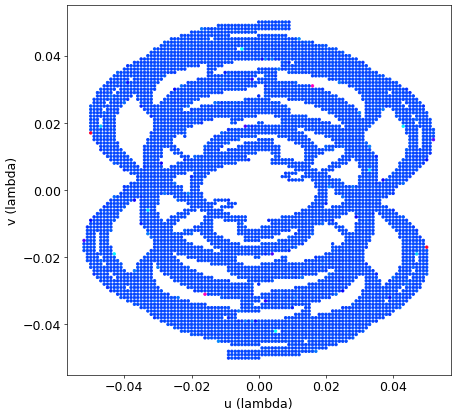

In [1237]:
# plot visibility data
fig=plt.figure(figsize=(15,8))
ax=fig.add_subplot(111)
meters_u = [u_val / 1000 for u_val in u]
meters_v = [v_val / 1000 for v_val in v]
ax.scatter(meters_u,meters_v, c=Re, marker='.', cmap='gist_rainbow')
ax.set_aspect(aspect=1.0)
ax.set_xlabel('u (lambda)')
ax.set_ylabel('v (lambda)')

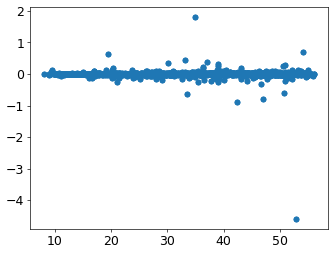

In [1238]:
plt.scatter(Rlambda, Re)

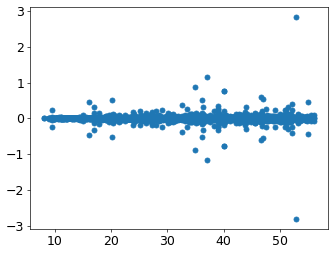

In [1239]:
plt.scatter(Rlambda, Im)

In [1240]:
np.average(Re)

np.float64(-0.0008188232681922277)

In [1241]:
np.average(Im)

np.float64(0.0)

In [1242]:
np.sum((np.array(Re)**2 + np.array(Im)**2)**(1/2)*np.array(w))/np.sum(w)

np.float64(0.0069745305719408745)

In [1243]:
orig = '../data/uv_test/orig.fits'
at = '../data/uv_test/at2024tvd.fits'
naive_uv_fit(at)

/var/folders/3j/z5bj43t10vsdnks2s1xw3vm80000gn/T/ipykernel_94532/2351528574.py:43: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  amp_red_chi2 = const_fn_red_chi2(amp_dat, float(amp_popt))
/var/folders/3j/z5bj43t10vsdnks2s1xw3vm80000gn/T/ipykernel_94532/2351528574.py:47: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  re_red_chi2 = const_fn_red_chi2(re_dat, float(re_popt))
/var/folders/3j/z5bj43t10vsdnks2s1xw3vm80000gn/T/ipykernel_94532/2351528574.py:51: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this opera

{'amp': {'val': 0.006974530566237036,
  'sd': 4035.85273676525,
  'red_chi2': 0.48303642995676704},
 're': {'val': 0.0004904882554896553,
  'sd': 171.8119936652506,
  'red_chi2': 0.4873412477494087},
 'im': {'val': -2.7391005396064185e-07,
  'sd': 0.03651166785822786,
  'red_chi2': 0.5192661783285399}}

0.0005026188079394258
0.00012499547090397443
-2.2234667865760685e-05
0.00012571608158715614


(State([[0.00694139]
  [0.0071776 ]
  [0.00703508]], log_prob=[-1347.46325192 -1348.67443879 -1347.54074581], blobs=None, random_state=('MT19937', array([3425499425, 1805322969, 2836658821,  245325214, 1310228271,
        2486270411, 3277040943, 1461131623, 3897445040,  651046868,
        2734481510, 4250133102, 2932877711, 2748226091, 3174006226,
         727811572, 3230226229,  844536383, 1431384396, 2794754986,
        3974920228, 3679178050,  316129138, 2368854517, 2314783206,
        2410173886, 1089052898,  444157636,  530183583, 3312434885,
        1573035553, 1914359377, 2846186629, 1908699547,  493474060,
           8747701, 4182734332, 3591098903, 3730683115, 4272399822,
        2878646571, 3153489767,  526393606, 2418188213, 3373904956,
        3907730998, 2809855436,  357497029, 1936496054,  254743528,
        2714282766, 2044404990, 1206486439, 2933212212, 2238923725,
          63379613, 1117027790, 3772303600,  170729228,  496488791,
        3387333857,  263217963, 164678

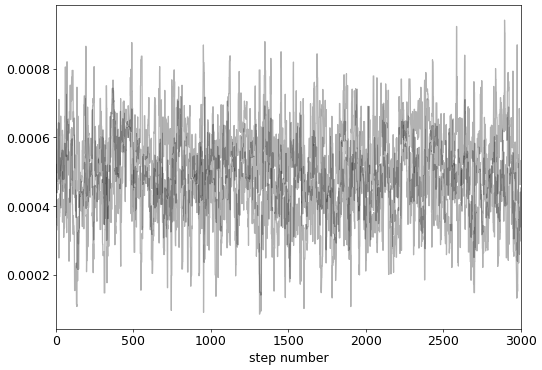

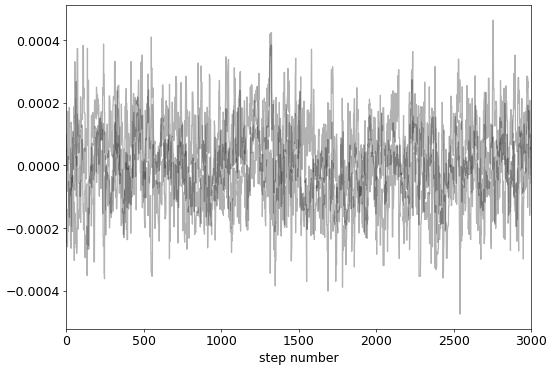

In [1244]:
mcmc_uv_fit(at)